In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dispersion
import orbitcreation
import conductivity
from makesigmalist import makelist_parallel
from time import time

In [12]:
thetalist = np.linspace(-14,99,80)

res_z = 20
res_xy = 100

fixedparams = [190e-3,-0.134,0.067,0.805] #T,T1multvalue,T11multvalue,mumultvalue

def create_rhozz(phi,Bmag,params):
    dispersionInstance = dispersion.LSCOdispersion(T=fixedparams[0],T1multvalue=fixedparams[1],T11multvalue=fixedparams[2],Tzmultvalue=params[0],mumultvalue=fixedparams[3])

    #0.22 params
    #T= 190e-3,T1multvalue=-0.134,T11multvalue=0.067,Tzmultvalue=Tzmultvalue,mumultvalue=0.805

    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    starttime = time()
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    calculated_doping = FSorbitsInstance.calculateDoping()
    endtime = time()
    print(f"Time taken to create Fermi Surface = {endtime - starttime}. Doping = {calculated_doping}%")

    def create_rhozz(phi,Bmag):
        phi_rad = np.deg2rad(phi)

        conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=params[1],invtau_aniso=params[2])
        starttime = time()
        conductivityInstance.createAmatrix_Bindependent()
        endtime = time()
        print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

        def getsigma(theta):
            B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
            conductivityInstance.createAmatrix_Bdependent(B)
            conductivityInstance.createAlpha()
            conductivityInstance.createSigma()

            #print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
            return conductivityInstance.sigma,conductivityInstance.areasum

        sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist)
        rhozzlist= [rho[2,2]*10e-5 for rho in rholist]

        return rhozzlist
    
    rhozzlist = create_rhozz(phi=phi,Bmag=Bmag)

    return rhozzlist

def create_rhoxy(B_caxis,params):
        dispersionInstance = dispersion.LSCOdispersion(T=fixedparams[0],T1multvalue=fixedparams[1],T11multvalue=fixedparams[2],Tzmultvalue=params[0],mumultvalue=fixedparams[3])

        FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
        FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)

        conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=params[1],invtau_aniso=params[2])
        conductivityInstance.createAmatrix_Bindependent()

        Bmag = B_caxis
        B = [0,0,Bmag]
        conductivityInstance.createAmatrix_Bdependent(B)
        conductivityInstance.createAlpha()
        conductivityInstance.createSigma()

        sigma = conductivityInstance.sigma
        rho = np.linalg.inv(sigma)
        rhoxy= rho[0,1]*10e-5

        return rhoxy

def calc_rhoxx(B_caxis,params):
    dispersionInstance = dispersion.LSCOdispersion(T=fixedparams[0],T1multvalue=fixedparams[1],T11multvalue=fixedparams[2],Tzmultvalue=params[0],mumultvalue=fixedparams[3])

    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)

    conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=params[1],invtau_aniso=params[2])
    conductivityInstance.createAmatrix_Bindependent()

    Bmag = B_caxis
    B = [0,0,Bmag]
    conductivityInstance.createAmatrix_Bdependent(B)
    conductivityInstance.createAlpha()
    conductivityInstance.createSigma()

    sigma = conductivityInstance.sigma
    rhoxx = np.linalg.inv(sigma)[0,0]*10e-5

    return rhoxx

In [3]:
Tlist = [20,25,30,35,40,50,70,100]
paramslist = []

for temp in Tlist:
    filename = f"fit_logs_only22perc30deg/fit_logs_22perc_{temp}K.txt"
    cost,Tzmultvalue,invtau_iso,invtau_aniso = np.loadtxt(filename,unpack=True,skiprows=5,delimiter=",")
    min_index = np.argmin(cost)
    paramslist.append((Tzmultvalue[min_index],invtau_iso[min_index],invtau_aniso[min_index]))
    print((Tzmultvalue[min_index],invtau_iso[min_index],invtau_aniso[min_index]))

rhozzlist30 = []
rhoxylist = []
data_rhozz30list = []
data_theta30list = []

for T,params in zip(Tlist,paramslist):

    #load data
    data_theta30,data_rhozz30 = np.loadtxt(f"data/2601C/2601C_phi30_T{T}K_B41.5T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta30list.append(data_theta30)
    data_rhozz30list.append(data_rhozz30)

    #generate data
    rhozzlist30.append(create_rhozz(phi=30,Bmag=41.5,params=params))
    rhoxylist.append(create_rhoxy(B_caxis=9,params=params))

(np.float64(0.07966931585934785), np.float64(10.598389728447907), np.float64(177.50036851306916))
(np.float64(0.07966931585934785), np.float64(12.32748079365468), np.float64(178.80594558258593))
(np.float64(0.07966931585934785), np.float64(13.228934739735276), np.float64(185.44919841827928))
(np.float64(0.07973514300853901), np.float64(14.392862368230897), np.float64(190.44150808044088))
(np.float64(0.07966931585934785), np.float64(15.305772351538758), np.float64(195.90253866084075))
(np.float64(0.07966931585934785), np.float64(19.100276485332547), np.float64(194.93111608738644))
(np.float64(0.07966931585934785), np.float64(26.569680720793194), np.float64(196.4589950354929))
(np.float64(0.07966931585934785), np.float64(40.68929096752363), np.float64(193.7775233233292))
Time taken to create Fermi Surface = 0.06341552734375. Doping = 0.23331134869494008%
Time taken to create B independent Amatrix =  0.5576412677764893
Time taken to create Fermi Surface = 0.06136775016784668. Doping = 0.2

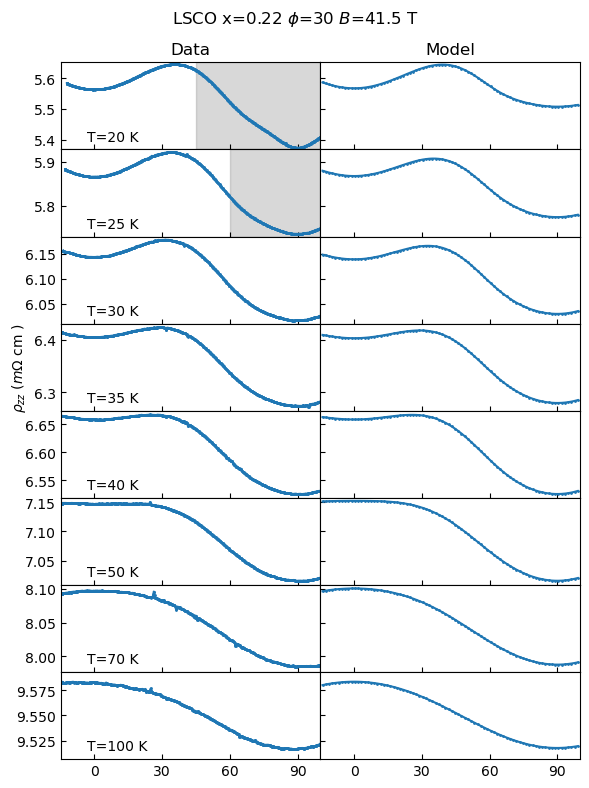

In [5]:
fig,axes = plt.subplots(nrows=8,ncols=2,figsize=(6,8),sharex=True)

for T,row,params,data_theta30,data_rhozz30,rhozz30,rhoxy in zip(Tlist,axes,paramslist,data_theta30list,data_rhozz30list,rhozzlist30,rhoxylist):
    row[1].plot(thetalist,rhozz30,ls="-",marker="o",ms=1)
    row[0].plot(data_theta30,data_rhozz30,ls="-",marker="o",ms=1)
    row[1].set_yticklabels([])
    row[0].text(0.1,0.1,f"T={T} K",fontsize=10, transform=row[0].transAxes)

    for column in row:
        column.set_ylim(np.min(data_rhozz30)*0.999,np.max(data_rhozz30)*1.001)
        column.tick_params(direction='in')
    
axes[3,0].set_ylabel(r"$\rho_{zz}$ ($m\Omega$ cm )")
axes[0,0].set_title("Data")
axes[0,1].set_title("Fit")

axes[6,0].set_xlabel(r'$\theta$')
axes[6,1].set_xlabel(r'$\theta$')
axes[0,0].set_title("Data")
axes[0,1].set_title("Model")

axes[0,0].axvspan(45, 120, alpha=0.3, color='gray')
axes[1,0].axvspan(60, 120, alpha=0.3, color='gray')
axes[0,0].set_xlim(-15,100)
#row[0].text(0.1,0.1,f"LSCO x=0.22\nT={T} K\nRes={res_z}x{res_xy}",fontsize=10, transform=row[0].transAxes)

for column in [axes[6,0],axes[7,1]]:
    column.set_xticks([0,30,60,90])

#make vspace 0
fig.suptitle("LSCO x=0.22 "+r"$\phi$=30 $B$=41.5 T",fontsize=12)
fig.tight_layout()
plt.subplots_adjust(hspace=0.0,wspace=0.0)

Text(0.1, 0.8, 'LSCO x=0.22\nRes=20x100')

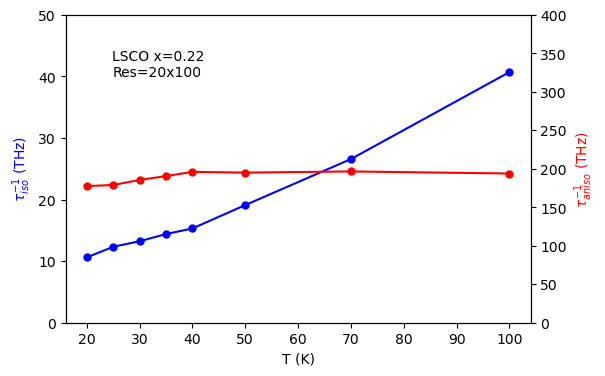

In [6]:
#plotting scattering rates
fig,axes = plt.subplots(figsize=(6,4))
axes2 = axes.twinx()

invtau_iso_list = [params[1] for params in paramslist]
invtau_aniso_list = [params[2] for params in paramslist]

axes.plot(Tlist,invtau_iso_list,ls="-",marker="o",ms=5,label=r"$\tau_{iso}^{-1}$",color="blue")
axes.set_ylabel(r"$\tau_{iso}^{-1}$ (THz)",color="blue")
axes.set_ylim(0,50)

axes2.plot(Tlist,invtau_aniso_list,ls="-",marker="o",ms=5,label=r"$\tau_{aniso}^{-1}$",color="red")
axes2.set_ylabel(r"$\tau_{aniso}^{-1}$ (THz)",color="red")
axes.set_xlabel("T (K)")
axes2.set_ylim(0,400)

axes.text(0.1,0.8,f"LSCO x=0.22\nRes={res_z}x{res_xy}",fontsize=10, transform=axes.transAxes)

<>:8: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
<>:8: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
C:\Users\Sahas\AppData\Local\Temp\ipykernel_10704\3083946987.py:8: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
  data_Trhoxx,data_rhoxx = np.loadtxt(f"ppms data\LSCO 2601D and E_Resistivity vs T_2K to 300K.dat",unpack=True,skiprows=31,delimiter=",",usecols=(3,6))


[np.float64(19.972286620610163), np.float64(22.818222447799666), np.float64(24.382813416705453), np.float64(26.337164907793632), np.float64(27.89175710461117), np.float64(33.83395985850692), np.float64(45.209422122244256), np.float64(65.59608544254435)]


(0.0, 90.0)

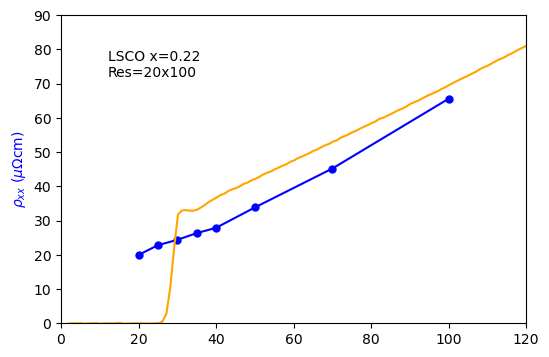

In [13]:
#plotting rhoxx
fig,axes = plt.subplots(figsize=(6,4))

rhoxx_list = [calc_rhoxx(0,params)*1e3 for params in paramslist]
print(rhoxx_list)

#load rhoxx data
data_Trhoxx,data_rhoxx = np.loadtxt(f"ppms data\LSCO 2601D and E_Resistivity vs T_2K to 300K.dat",unpack=True,skiprows=31,delimiter=",",usecols=(3,6))

axes.plot(Tlist,rhoxx_list,ls="-",marker="o",ms=5,label=r"$\rho_{xx}$",color="blue")
axes.plot(data_Trhoxx,data_rhoxx*1e6,ls="-",label="Data",color="orange")
axes.set_ylabel(r"$\rho_{xx}$ ($\mu\Omega$cm)",color="blue")

axes.text(0.1,0.8,f"LSCO x=0.22\nRes={res_z}x{res_xy}",fontsize=10, transform=axes.transAxes)

axes.set_xlim(0,120)
axes.set_ylim(0,90)

In [8]:
rhoxy_list = [create_rhoxy(B_caxis=9,params=params)*1e3 for params in paramslist]
print(rhoxy_list)

#load rhoxy data
data_Trhoxy,data_rhoxy = np.loadtxt(f"ppms data\LSCO 2601F and G_Resistivity vs T at 9T_symmetrized.csv",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

<>:5: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
<>:5: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
C:\Users\Sahas\AppData\Local\Temp\ipykernel_10704\2252064423.py:5: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
  data_Trhoxy,data_rhoxy = np.loadtxt(f"ppms data\LSCO 2601F and G_Resistivity vs T at 9T_symmetrized.csv",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))


[np.float64(0.36686866255501194), np.float64(0.3603332310965834), np.float64(0.3589825522762944), np.float64(0.35631561014785557), np.float64(0.35482754725987686), np.float64(0.34321798705550327), np.float64(0.3264376774313401), np.float64(0.3037848751286466)]


(0.0, 0.7)

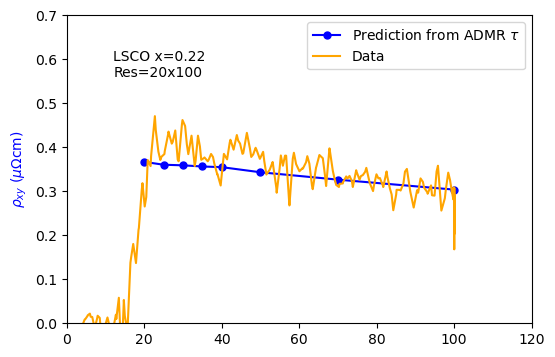

In [9]:
#plotting rhoxy
fig,axes = plt.subplots(figsize=(6,4))

axes.plot(Tlist,rhoxy_list,ls="-",marker="o",ms=5,color="blue",label=r"Prediction from ADMR $\tau$")
axes.plot(data_Trhoxy,data_rhoxy,ls="-",color="orange",label=r"Data")
axes.set_ylabel(r"$\rho_{xy}$ ($\mu\Omega$cm)",color="blue")

axes.text(0.1,0.8,f"LSCO x=0.22\nRes={res_z}x{res_xy}",fontsize=10, transform=axes.transAxes)
axes.legend(loc="upper right")

axes.set_xlim(0,120)
axes.set_ylim(0,0.7)

<>:5: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
<>:5: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
C:\Users\Sahas\AppData\Local\Temp\ipykernel_10704\1007935035.py:5: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
  data_Trhoxx,data_rhoxx = np.loadtxt(f"ppms data\LSCO 2601D and E_Resistivity vs T_2K to 300K.dat",unpack=True,skiprows=31,delimiter=",",usecols=(3,6))


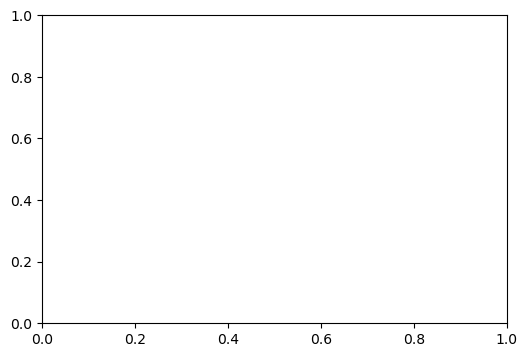

In [ ]:
#load rhoxx data
data_Trhoxx,data_rhoxx = np.loadtxt(f"ppms data\LSCO 2601D and E_Resistivity vs T_2K to 300K.dat",unpack=True,skiprows=31,delimiter=",",usecols=(3,6))

B_list = np.linspace(0,45,20)
rhoxx_list_vsB = [[calc_rhoxx(B,params)*1e3 for B in B_list] for params in paramslist] 

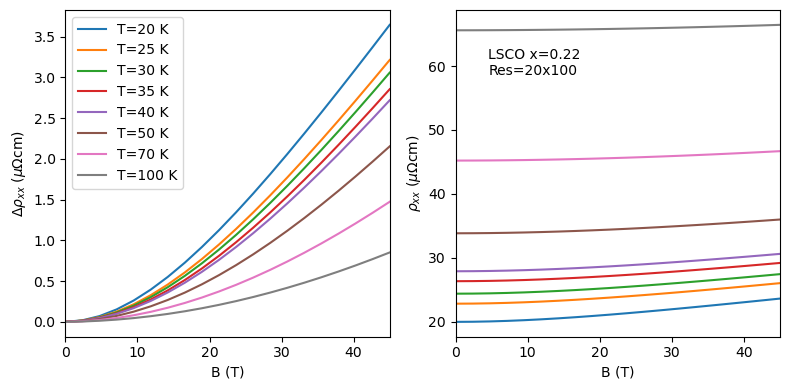

In [30]:
#plotting rhoxx vs B
fig,(axes,axes1) = plt.subplots(nrows=1,ncols=2,figsize=(8,4))

for rhoxx_list,T in zip(rhoxx_list_vsB,Tlist):
    axes.plot(B_list,rhoxx_list - rhoxx_list[0],ls="-",label=f"T={T:.0f} K")
    axes1.plot(B_list,rhoxx_list,ls="-",label=f"T={T:.0f} K")

axes.set_ylabel(r"$\Delta\rho_{xx}$ ($\mu\Omega$cm)")   
axes1.set_ylabel(r"$\rho_{xx}$ ($\mu\Omega$cm)")   

axes.set_xlabel("B (T)")
axes1.set_xlabel("B (T)")
axes1.text(0.1,0.8,f"LSCO x=0.22\nRes={res_z}x{res_xy}",fontsize=10, transform=axes1.transAxes)

axes.legend(loc="upper left")

axes.set_xlim(0,45)
axes1.set_xlim(0,45)
#axes.set_ylim(0,90)

fig.tight_layout()